# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Heart Disease Dataset](https://www.kaggle.com/datasets/srisyra02/synthetic-heart-disease-risk-analysis)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('heart_disease.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,2,107,196.0,1.0,0.0,159.0,0.0,1.8,2.0,0.0,?,0
1,66,1,2,112,240.0,?,0.0,148.0,0.0,0.7,2.0,0.0,?,0
2,60,0,2,123,209.0,0.0,0.0,114.0,0.0,1.1,2.0,1.0,3.0,1
3,49,0,3,105,167.0,0.0,0.0,142.0,0.0,0.1,1.0,1.0,3.0,0
4,49,1,2,114,261.0,0.0,0.0,188.0,1.0,0.1,3.0,0.0,7.0,1


## last Five row

In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
4995,38,0,2,128,211.0,0.0,0.0,155.0,0.0,1.6,1.0,0.0,7.0,0
4996,65,1,2,134,252.0,0.0,1.0,132.0,1.0,2.0,2.0,0.0,7.0,1
4997,68,1,4,147,254.0,0.0,1.0,152.0,0.0,2.0,2.0,0.0,7.0,1
4998,61,1,4,116,284.0,1.0,0.0,158.0,0.0,0.2,?,0.0,?,0
4999,52,1,2,108,167.0,0.0,1.0,133.0,0.0,0.5,3.0,0.0,7.0,1


## Shape of our dataset

In [5]:
df.shape

(5000, 14)

## List out all columns

In [6]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
num           int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       5000 non-null   int64  
 1   sex       5000 non-null   int64  
 2   cp        5000 non-null   int64  
 3   trestbps  5000 non-null   int64  
 4   chol      5000 non-null   object 
 5   fbs       5000 non-null   object 
 6   restecg   5000 non-null   object 
 7   thalach   5000 non-null   object 
 8   exang     5000 non-null   object 
 9   oldpeak   5000 non-null   float64
 10  slope     5000 non-null   object 
 11  ca        5000 non-null   object 
 12  thal      5000 non-null   object 
 13  num       5000 non-null   int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 547.0+ KB


## Check Null Value

In [9]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,age,sex,cp,trestbps,oldpeak,num
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,52.432600,0.734200,2.703800,119.929600,0.960600,0.456200
std,14.464595,0.441802,1.028337,16.476837,0.706971,0.498128
min,28.000000,0.000000,1.000000,90.000000,0.000000,0.000000
25%,40.000000,0.000000,2.000000,108.000000,0.400000,0.000000
50%,52.000000,1.000000,3.000000,120.000000,0.900000,0.000000
75%,65.000000,1.000000,4.000000,131.000000,1.400000,1.000000
max,77.000000,1.000000,4.000000,178.000000,5.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

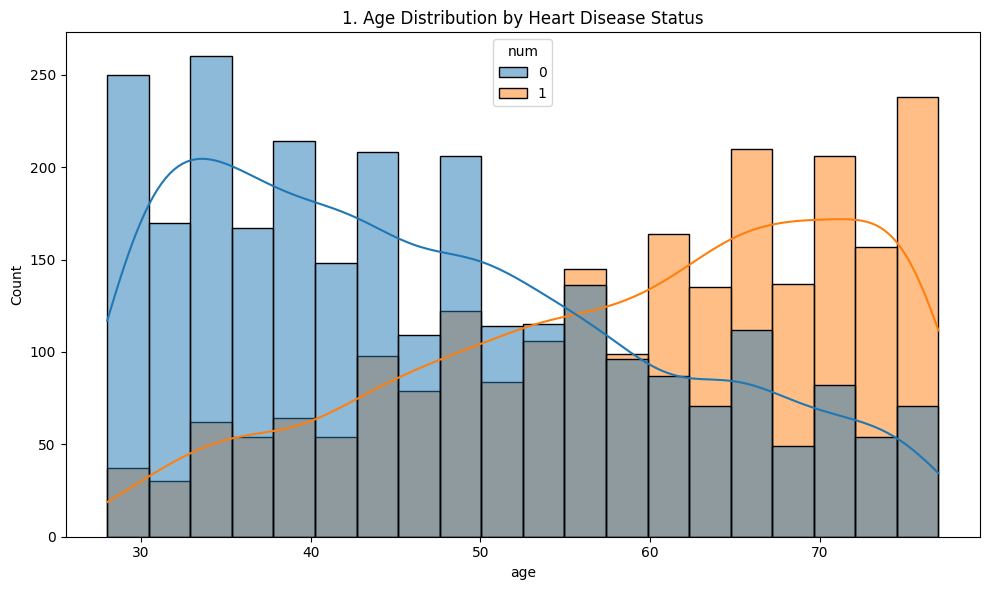

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='age', hue='num', kde=True, bins=20)
plt.title(f'{plot_no}. Age Distribution by Heart Disease Status')
show_fig()
plot_no += 1

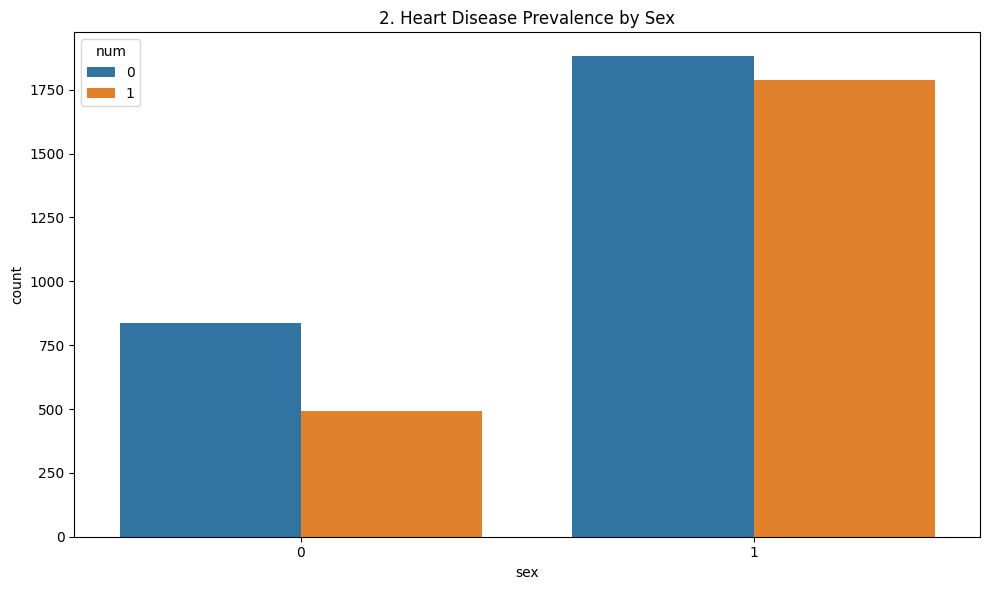

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='sex', hue='num')
plt.title(f'{plot_no}. Heart Disease Prevalence by Sex')
show_fig()
plot_no += 1

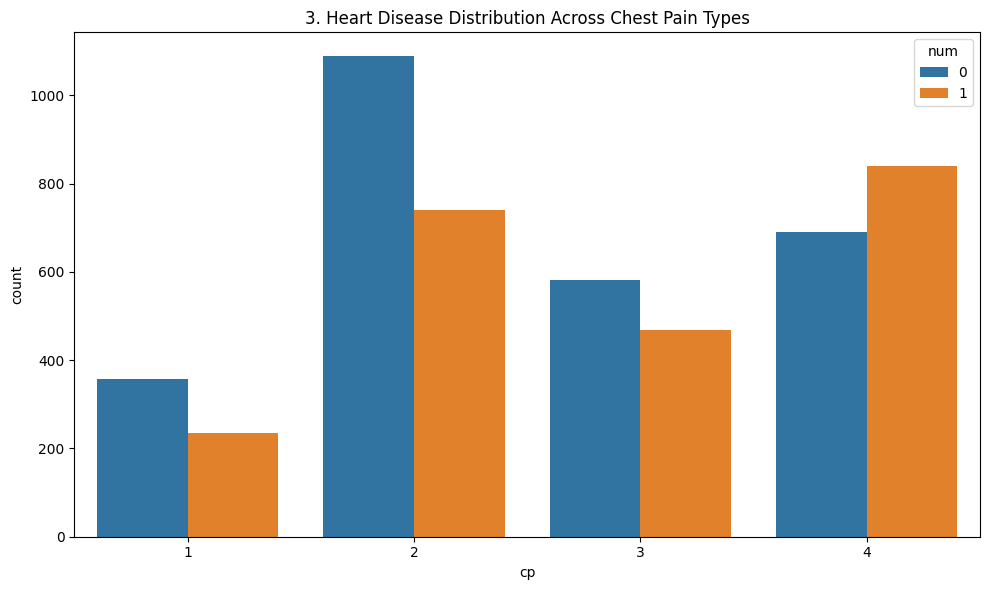

In [15]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='cp', hue='num')
plt.title(f'{plot_no}. Heart Disease Distribution Across Chest Pain Types')
show_fig()
plot_no += 1

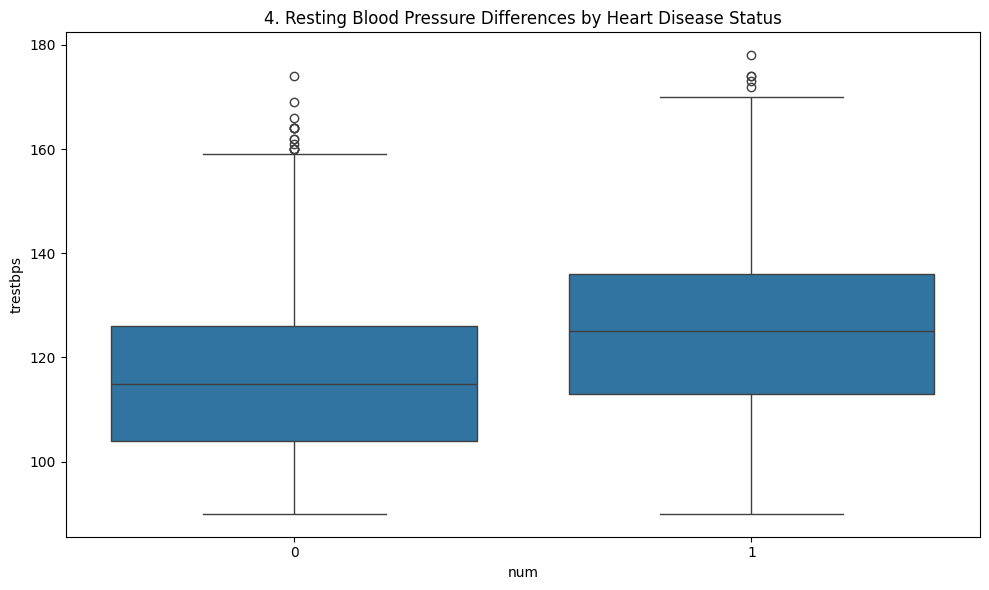

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='num', y='trestbps')
plt.title(f'{plot_no}. Resting Blood Pressure Differences by Heart Disease Status')
show_fig()
plot_no += 1

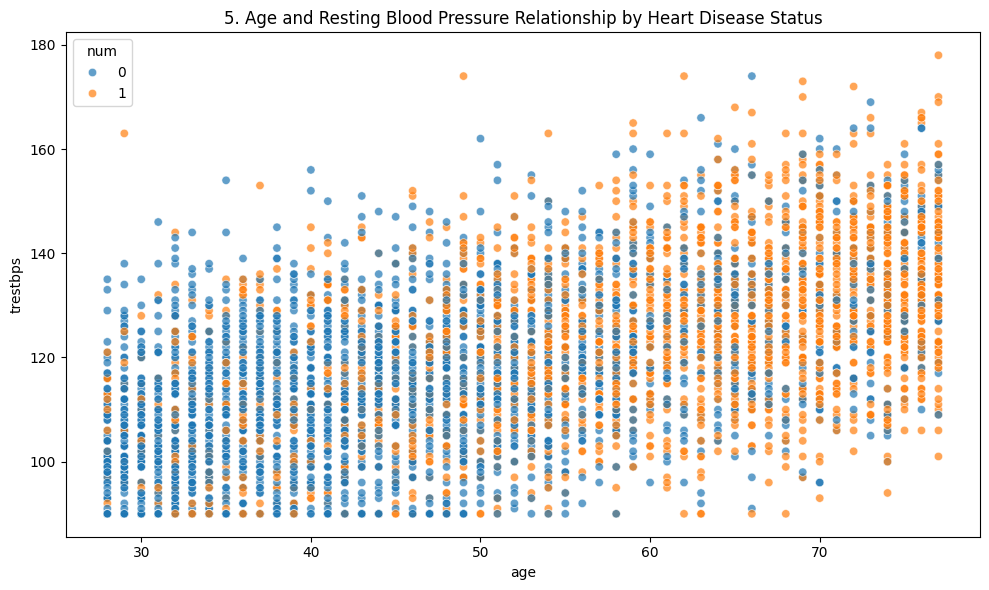

In [17]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='trestbps', hue='num', alpha=0.7)
plt.title(f'{plot_no}. Age and Resting Blood Pressure Relationship by Heart Disease Status')
show_fig()
plot_no += 1

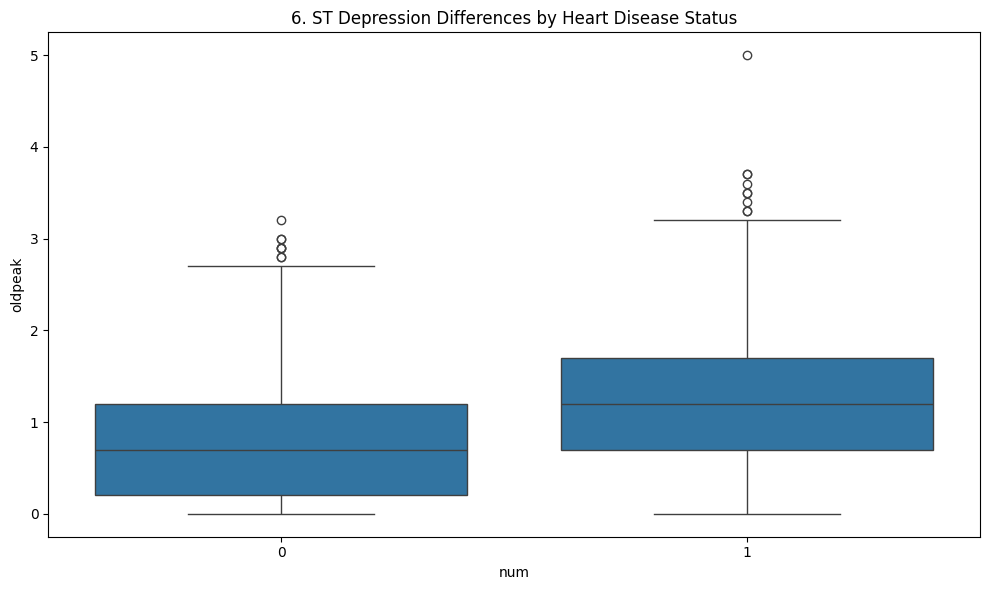

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='num', y='oldpeak')
plt.title(f'{plot_no}. ST Depression Differences by Heart Disease Status')
show_fig()
plot_no += 1

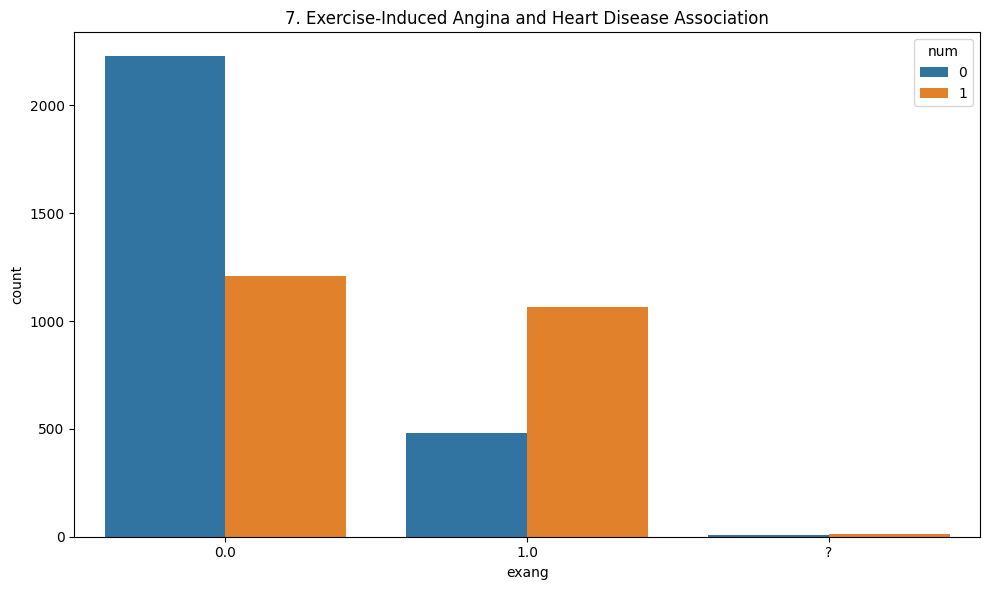

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='exang', hue='num')
plt.title(f'{plot_no}. Exercise-Induced Angina and Heart Disease Association')
show_fig()
plot_no += 1

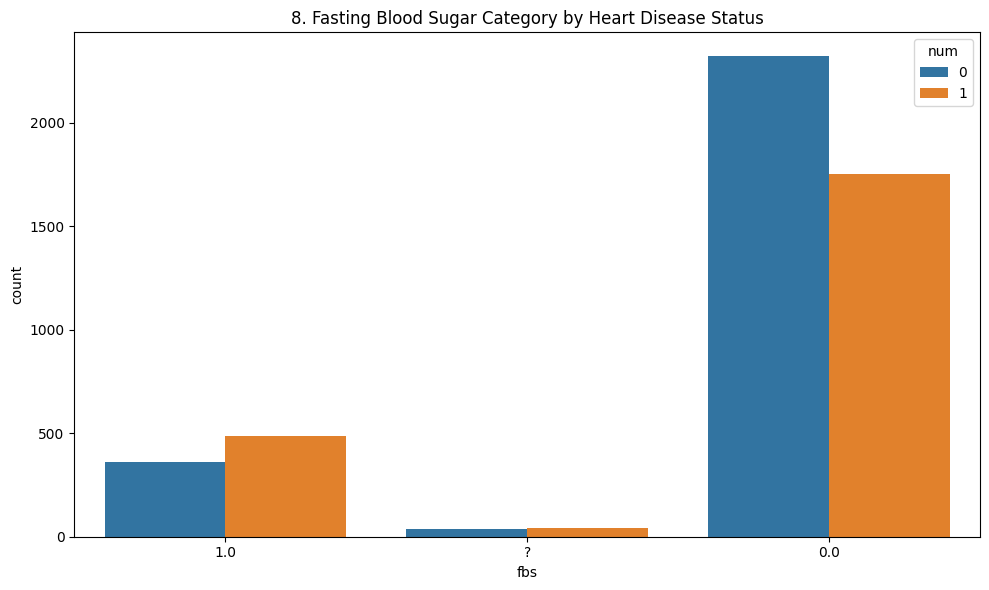

In [20]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='fbs', hue='num')
plt.title(f'{plot_no}. Fasting Blood Sugar Category by Heart Disease Status')
show_fig()
plot_no += 1

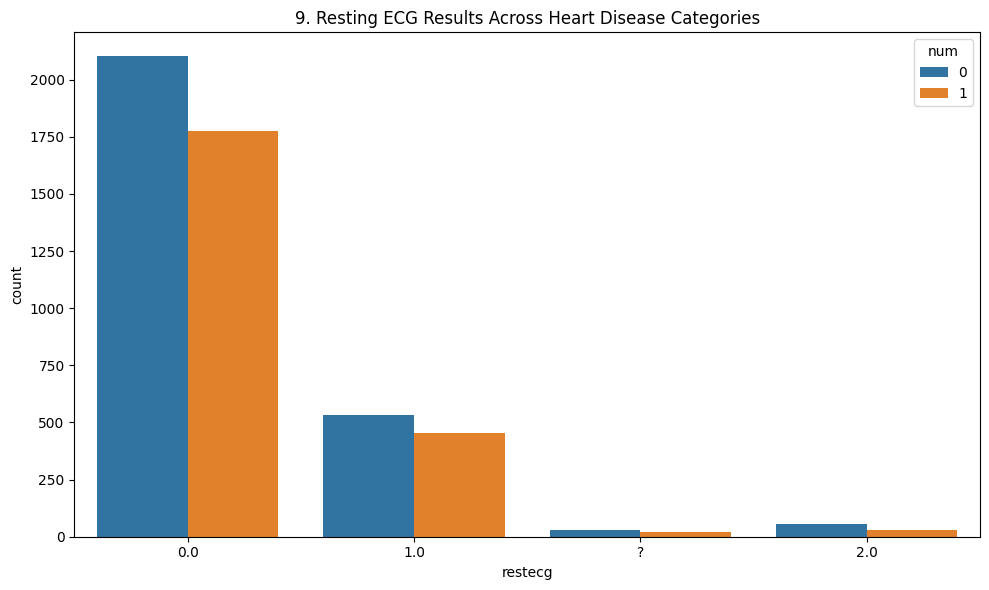

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='restecg', hue='num')
plt.title(f'{plot_no}. Resting ECG Results Across Heart Disease Categories')
show_fig()
plot_no += 1

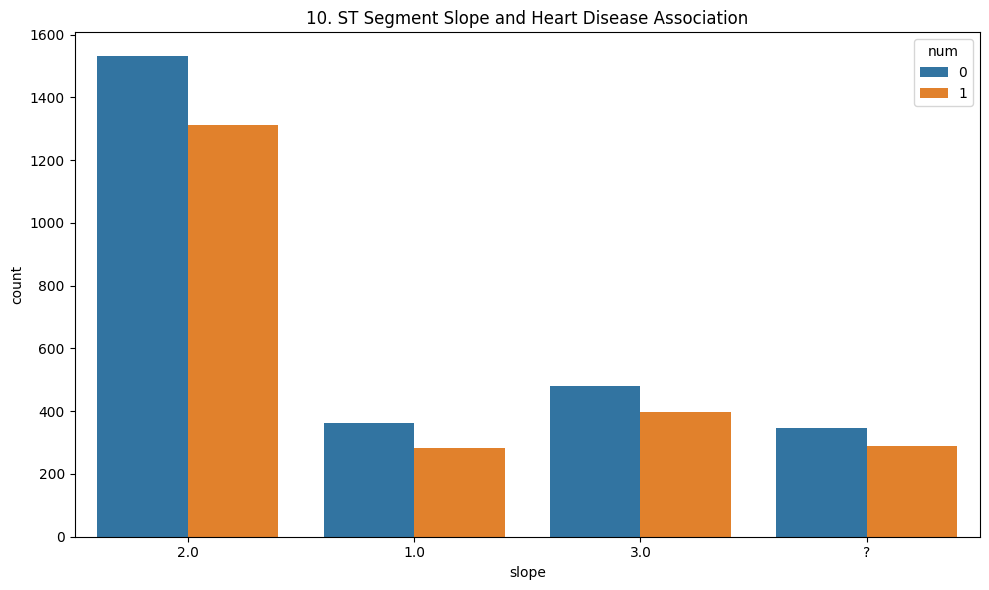

In [22]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='slope', hue='num')
plt.title(f'{plot_no}. ST Segment Slope and Heart Disease Association')
show_fig()
plot_no += 1

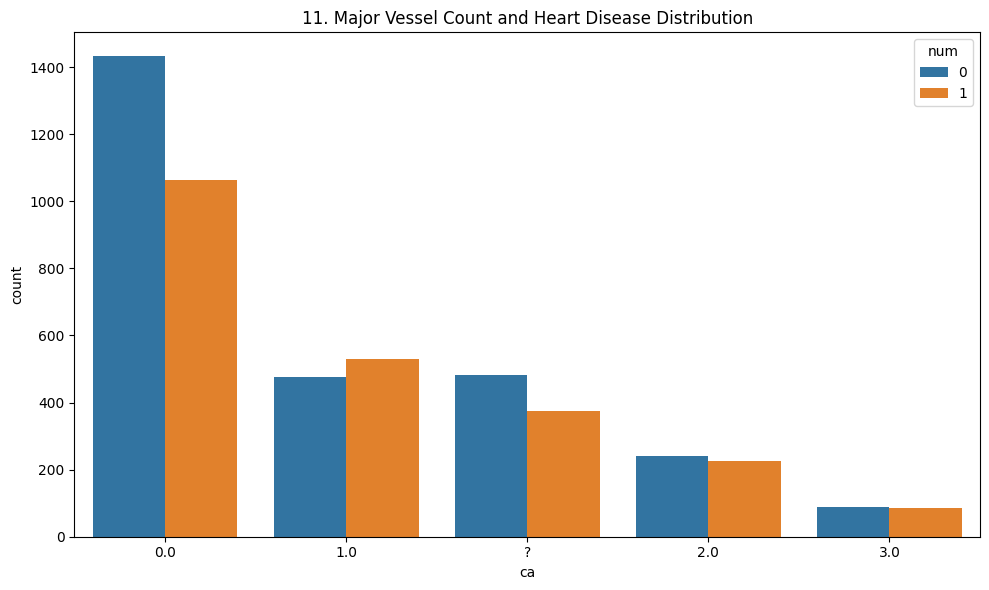

In [23]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='ca', hue='num')
plt.title(f'{plot_no}. Major Vessel Count and Heart Disease Distribution')
show_fig()
plot_no += 1

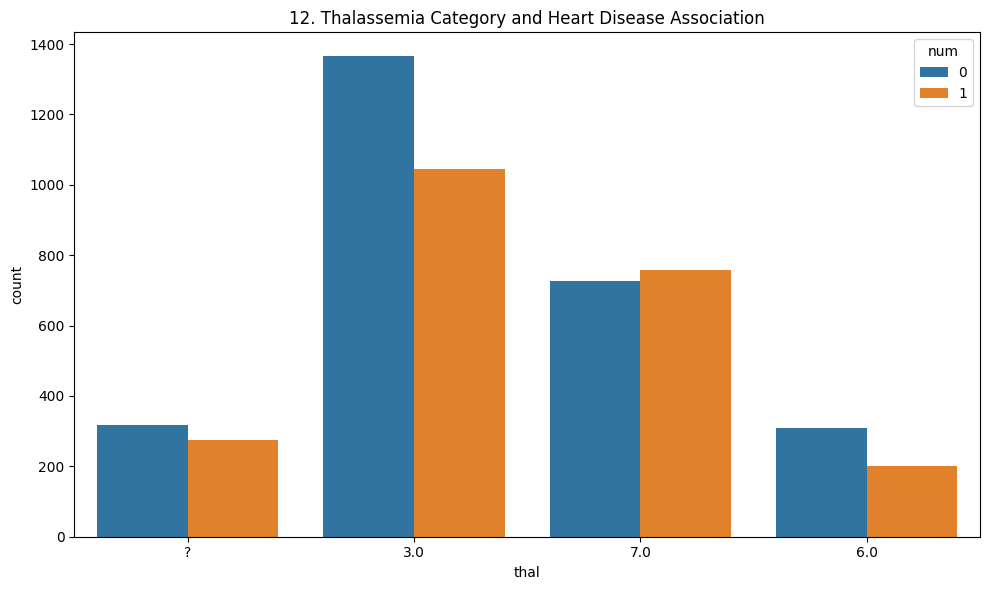

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='thal', hue='num')
plt.title(f'{plot_no}. Thalassemia Category and Heart Disease Association')
show_fig()
plot_no += 1

<Figure size 1000x600 with 0 Axes>

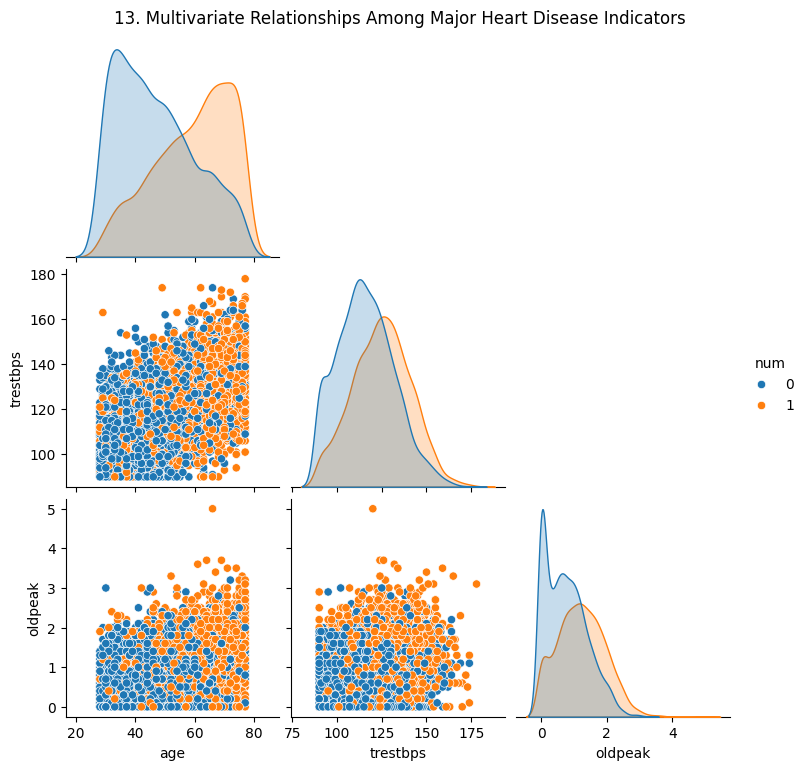

In [25]:
fig = plt.figure(figsize=(10,6))
sns.pairplot(df[['age','trestbps','chol','thalach','oldpeak','num']].dropna(), hue='num', corner=True)
plt.suptitle(f'{plot_no}. Multivariate Relationships Among Major Heart Disease Indicators', y=1.02)
plt.show()
plot_no += 1

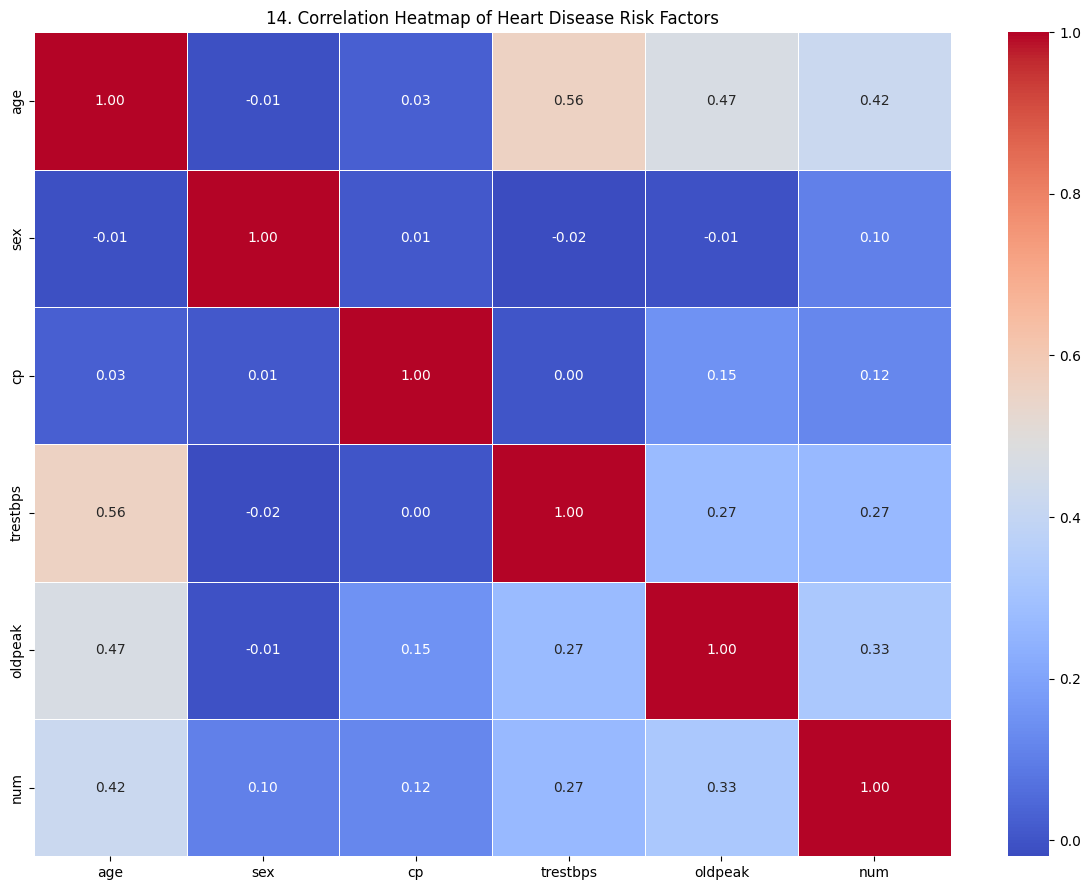

In [26]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title(f'{plot_no}. Correlation Heatmap of Heart Disease Risk Factors')
show_fig()
plot_no += 1

# Model Training

## Separate features and target

In [27]:
X = df.drop('num', axis=1)
y = df['num']

## Convert missing values into NaN

In [28]:
X = X.replace('?', pd.NA)
X = X.apply(pd.to_numeric, errors='coerce')

## Split data into training and testing sets

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

## Create preprocessing and Gradient Boosting model

In [30]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42
    ))
])

## Train the model

In [31]:
model.fit(X_train, y_train)

,steps,"[('imputer', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,loss,'log_loss'


## Generate predictions

In [32]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 71.60%


## Display classification report

In [34]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.73      0.74       544
           1       0.69      0.70      0.69       456

    accuracy                           0.72      1000
   macro avg       0.71      0.71      0.71      1000
weighted avg       0.72      0.72      0.72      1000



## Plot confusion matrix

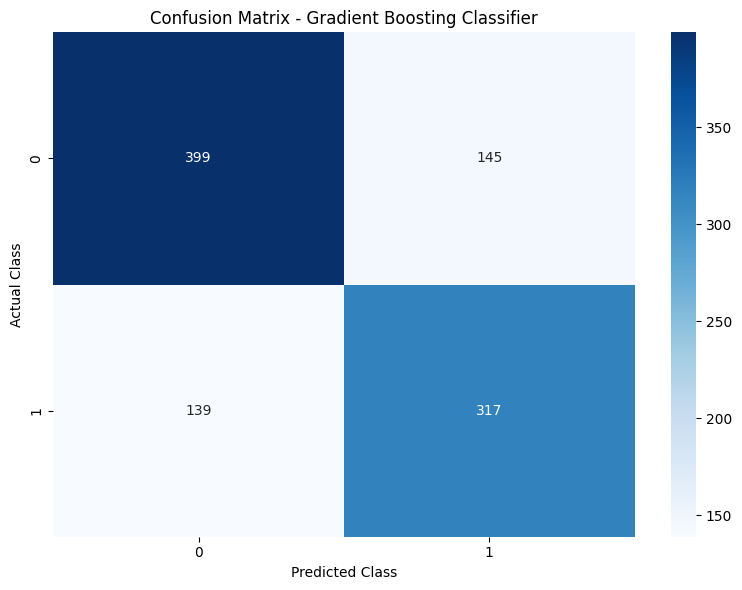

In [35]:
cm = confusion_matrix(y_test, y_pred)

fig = plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting Classifier')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()